In [4]:
!pwd

/users/khordadi


Plotting plan: Interpreter | num_aot=0 | bin_size=0 | e2e=1280620000000


TypeError: list indices must be integers or slices, not str

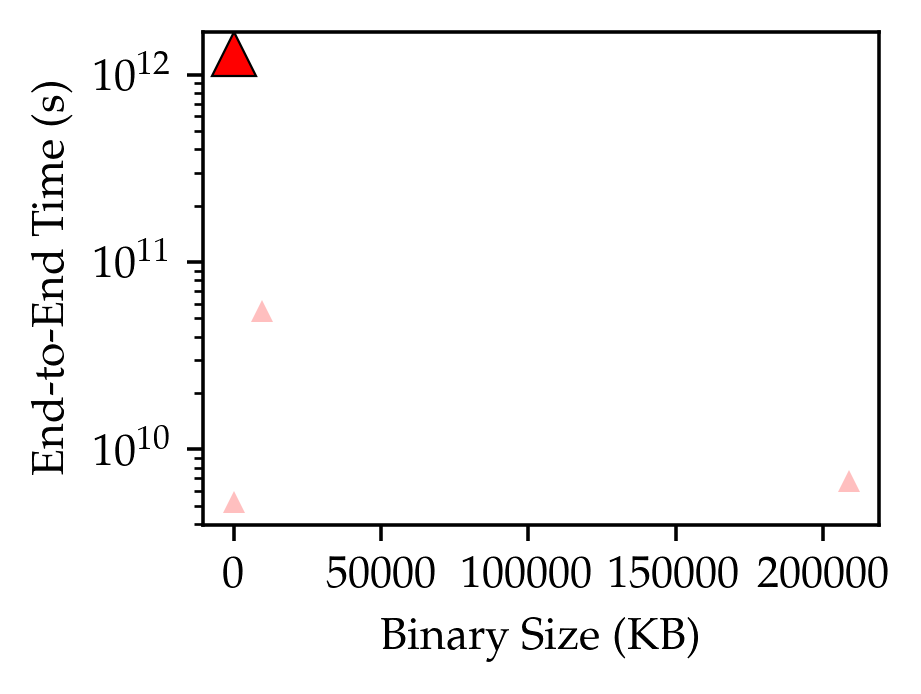

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import bokeh.palettes
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

gif_dir = '/tmp/truejit/evaluation/compilation-plan/out/gif'
# remove gif_dir
!rm -rf {gif_dir}
!mkdir -p {gif_dir}

cnt = 0
# for name, plan, num_aot, bin_size, e2e in data_points:
for i, evaluation in enumerate(evaluations):
    name = plans_titles[i]
    plan = plans[i]
    num_aot = plans[i]['mode'].value_counts().get('static', 0)
    bin_size = evaluation.dynamic_code_size
    e2e = evaluation.e2e
    print(f'Plotting plan: {name} | num_aot={num_aot} | bin_size={bin_size} | e2e={e2e}')

    fig = plt.figure(figsize=(15, 2), dpi=320)
    gs = GridSpec(1, 2, figure=fig, width_ratios=[4, 1])

    # =============================================
    ax = fig.add_subplot(gs[1])

    marker = '^'
    selected_marker_size = 10
    selected_alpha = 1
    colors = {
        'interp': 'orange',
        'jit': 'crimson',
        'aot': 'magenta',

        'caper': 'blue',

        'specialized': 'indigo',
        'bgjit': 'cyan',
    }
    colors = []
    colors.append('red')
    colors.append('blue')
    colors.append('green')
    colors.extend(bokeh.palettes.Viridis6[:])

    for j, ev in enumerate(evaluations):
        name_ = plans_titles[j]
        plan_ = plans[j]
        num_aot_ = plan_['mode'].value_counts().get('static', 0)
        bin_size_ = ev.dynamic_code_size
        e2e_ = ev.e2e
        color = colors[i]

        selected = True if name_ == name else False
        baselines = True if name_ in ['jit', 'aot', 'interp'] else False

        ax.plot(bin_size_, e2e_,
                # marker='X' if selected else 'v',
                marker=marker,
                color=color,
                markersize=selected_marker_size if selected or baselines else selected_marker_size / 2,
                alpha=1 if selected else .75 if baselines else .25,
                linewidth=0, linestyle='None',
                zorder=10 if selected or baselines else 0,
                markeredgecolor='black' if selected else 'none',
                markeredgewidth=.5 if selected else 0
                )

    ax.set_ylabel('End-to-End Time (s)')
    ax.set_xlabel('Binary Size (KB)')

    # make y log
    ax.set_yscale('log')

    # generate labels for marker and colors in legend
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], marker=marker, color='w', label='Interpret',
               markerfacecolor=colors['interp'], markersize=selected_marker_size),
        Line2D([0], [0], marker=marker, color='w', label='JIT',
               markerfacecolor=colors['jit'], markersize=selected_marker_size),
        Line2D([0], [0], marker=marker, color='w', label='AOT',
               markerfacecolor=colors['aot'], markersize=selected_marker_size),
        Line2D([0], [0], marker=marker, color='w', label='CAPER',
               markerfacecolor=colors['caper'], markersize=selected_marker_size),
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # plt.margins(.05)

    # plt.grid(True)

    # =============================================

    # ax = fig.add_subplot(gs[0])
    #
    # plan = plan['mode'].tolist()
    #
    # num_cols = 100
    # num_rows = (len(plan) // num_cols) + 1
    #
    # # remove 'caper' from colors
    # colors.pop('caper')
    #
    # mode_names = {
    #     'jit': 'JIT',
    #     'interp': 'Interpret',
    #     'specialized': 'Specialized',
    #     'aot': 'AOT',
    #     'bgjit': 'BGJIT'
    # }
    #
    # cell_size = 1
    #
    # for y in range(num_rows):
    #     for x in range(num_cols):
    #         if y * num_cols + x < len(plan):
    #             color = colors[plan[y * num_cols + x]]
    #             ax.add_patch(
    #                 plt.Rectangle((x, y), cell_size, cell_size, facecolor=color, edgecolor='white'))
    #         else:
    #             ax.add_patch(
    #                 plt.Rectangle((x, y), cell_size, cell_size, facecolor='white', edgecolor='white'))
    #
    # for y in range(num_rows):
    #     # val = (num_cols * num_rows) - ((y + 1) * num_cols)
    #     val = (y) * num_cols
    #     # if val % 200 == 0:
    #     ax.text(0 - cell_size / 2, y + cell_size / 2, str(val), ha='right', va='center')
    #
    # for x in range(num_cols):
    #     if (x + 1) % 10 == 0:
    #         ax.text(x + cell_size / 2, cell_size / 2 - 1, str(x + 1), ha='center', va='top')
    #
    # ax.set_xlim(0, num_cols)
    # ax.set_ylim(0, num_rows)
    # ax.set_aspect('equal')
    # ax.axis('off')
    #
    # textstr = ''
    # if name.startswith('caper_'):
    #     max_bin_size = int(name.split('_')[-1])
    #     textstr = f'CAPER: E2E Minimizer with Maximum {int(max_bin_size / 1e3)} KB Binary Size Constraint'
    # elif name == 'jit':
    #     textstr = f'Full JIT Compilation'
    # elif name == 'aot':
    #     textstr = f'Full AOT Compilation'
    # elif name == 'interp':
    #     textstr = f'Full Interpretation'
    # textstr += '\n' + f'Binary Size: {bin_size:.2f} KB | End-to-End Time: {e2e:.2f} s'
    # props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # # ax.text(0.5, -0.35, textstr, transform=ax.transAxes, verticalalignment='top', bbox=props, ha='center')
    #
    # # legend
    #
    # from matplotlib.lines import Line2D
    #
    # legend_elements = [Line2D([0], [0], marker='s', color='w', label=mode_names[mode],
    #                           markerfacecolor=color, markersize=10)
    #                    for mode, color in colors.items()]
    # ax.legend(handles=legend_elements, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.5), frameon=False)
    #
    # plt.tight_layout()
    #
    # # save as png
    # plt.savefig(f'{gif_dir}/{cnt}.png', bbox_inches='tight', dpi=320)
    # cnt += 1

    plt.show()

    break


In [433]:
import imageio.v2 as imageio

images = []
for i in range(cnt):
    filename = f'{gif_dir}/{i}.png'
    images.append(imageio.imread(filename))

imageio.mimsave(
    f'{gif_dir}/compilation_plan.gif',
    images,
    # add delay
    fps=2,

)

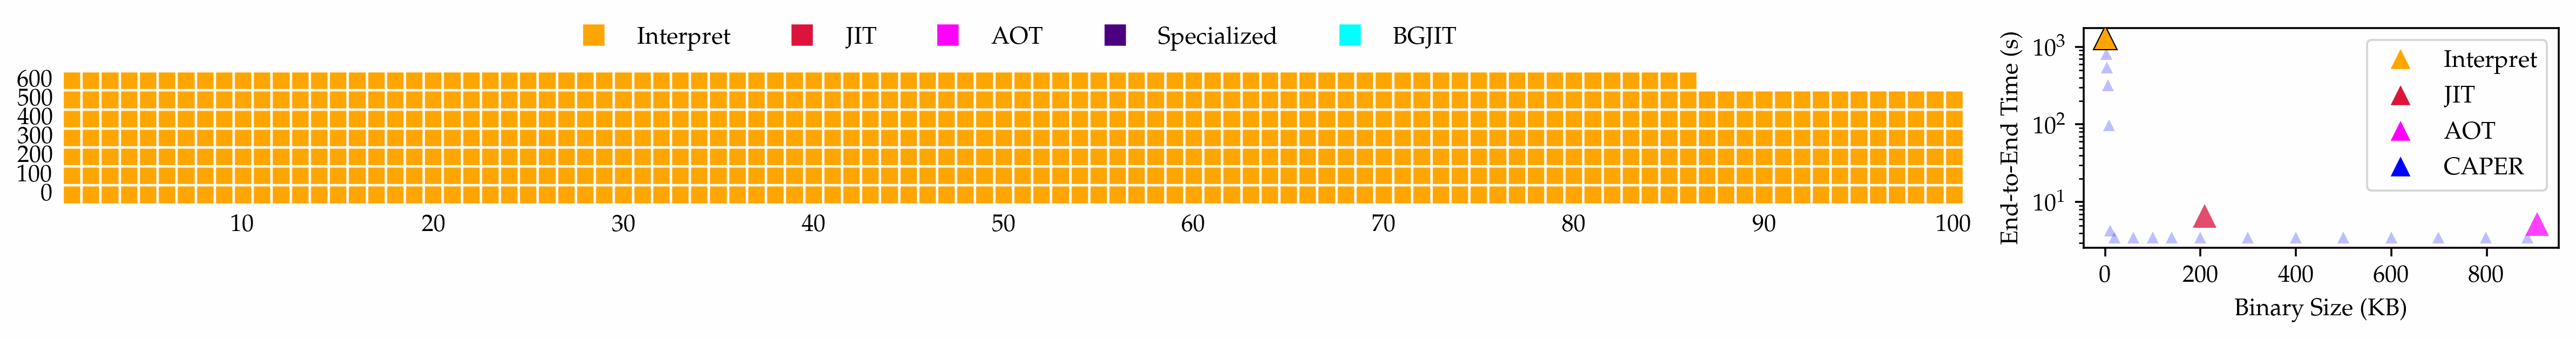

In [434]:
# show the gif
from IPython.display import Image

Image(filename=f'{gif_dir}/compilation_plan.gif')